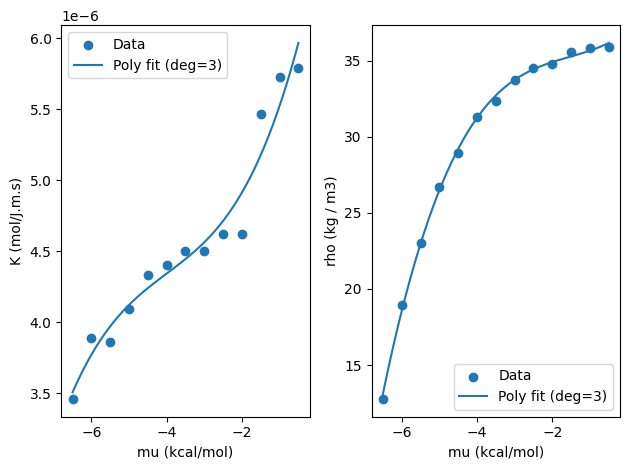

In [1]:
import numpy as np
import matplotlib.pyplot as plt

V = 4e-9 * 4e-9 * 2e-9 # m3
m = 1e-3 # kg/mol
Na = 6.022e23 # 1/mol

# Load data
K_data = np.loadtxt("T300/K_vs_mu.dat")
N_data = np.loadtxt("T300/N_vs_mu.dat")

# Split into x and y
mu_K, K = K_data[:, 0], K_data[:, 1]
mu_N, N = N_data[:, 0], N_data[:, 1]
rho = m * N / V / Na # kg/m3

# Fit
degree = 3
coeffs_K = np.polyfit(mu_K, K, degree)
degree = 3
coeffs_rho = np.polyfit(mu_N, rho, degree)

# Create polynomial functions
poly_K = np.poly1d(coeffs_K)
poly_rho = np.poly1d(coeffs_rho)

mu_fit = np.linspace(min(mu_K), max(mu_K), 200)

K_fit = poly_K(mu_fit)
rho_fit = poly_rho(mu_fit)

with open("T300/K_vs_mu_fit.txt", "w") as f:
    f.write(f"{degree}\n")
    for c in coeffs_K:
        f.write(f"{c}\n")

with open("T300/rho_vs_mu_fit.txt", "w") as f:
    f.write(f"{degree}\n")
    for c in coeffs_rho:
        f.write(f"{c}\n")

plt.figure()

# K vs mu
plt.subplot(1, 2, 1)
plt.scatter(mu_K, K, label="Data")
plt.plot(mu_fit, K_fit, label=f"Poly fit (deg={degree})")
plt.xlabel("mu (kcal/mol)")
plt.ylabel("K (mol/J.m.s)")
plt.legend()

# N vs mu
plt.subplot(1, 2, 2)
plt.scatter(mu_N, rho, label="Data")
plt.plot(mu_fit, rho_fit, label=f"Poly fit (deg={degree})")
plt.xlabel("mu (kcal/mol)")
plt.ylabel("rho (kg / m3)")
plt.legend()

plt.tight_layout()
plt.show()
